In [1]:
from function_lib import *

In [4]:
# ----------------- config -----------------
n_simulation = 30          # number of seeds (= number of instances in the pickle)
degs = [1, 2, 4, 6, 8]
n_instance = 100     # num_instances per seed
mult_noises = [0, 0.5]
grid_width = 4
input_dim = grid_width
# ----------------- paths ------------------
base_path = change_to_py_file_dir()
parent_path = str(Path(base_path).parent)
base      = os.path.join(parent_path, "Data", "Shortest_path")

sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
Z = np.vstack(sols)  # (K, m), m = number of edges = d_c

A, b = build_incidence_matrix_and_b(edges, G)
d_c = Z.shape[1]           # number of edges
d_p = len(G.nodes())       # number of nodes
model_list = ["MLE-1", "LST-0.01", "LST-1", "LST-100", "LST-10000", "LST-1000000", "SPO", "DIO-0.0001", "DIO-1", "PAR-0.0000001", "PAR-0.1", "PAR-10"]

In [5]:

total_result = []

for deg in degs:
    for noise in mult_noises:
        for model_type in model_list:

            # ---- Parse model + eta ----
            if "-" in model_type:
                model_name, eta = model_type.split("-", 1)
                eta = float(eta)
            else:
                model_name = model_type
                eta = 1.0

            regret_result = []
            param_result = []

            solver = None  # build solver ONCE per model/deg/noise

            for seed in tqdm(range(n_simulation),
                             desc=f"Model {model_type} | deg={deg} noise={noise}",
                             colour="green"):

                random.seed(seed)
                np.random.seed(seed)

                # ---- Data for this seed ----
                x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
                    base, n_instance, input_dim, deg, noise, grid_width, seed
                )

                # ------------------------------
                # MLE
                # ------------------------------
                if model_name == "MLE":
                    if solver is None:
                        solver = MLEECPParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            Z=sols,
                            eta=eta
                        )
                    res = solver.solve(x_train, y_train, verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ------------------------------
                # LST
                # ------------------------------
                elif model_name == "LST":
                    if solver is None:
                        solver = LSTECPParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            Z=sols,
                            eta=eta
                        )
                    res = solver.solve(x_train, y_train, verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ------------------------------
                # SPO
                # ------------------------------
                elif model_name == "SPO":
                    if solver is None:
                        solver = SPOShortestPathParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            d_p=d_p,   # known externally
                            A=A.T,
                            b=b
                        )
                    Zstar_train = compute_z_star_batch(y_train, Z)
                    res = solver.solve(x_train, y_train, Zstar_train, verbose=False)
                    eval_res = solver.evaluate_regret(
                        X_test=x_test, C_test=y_test, Z=Z, return_per_sample=False
                    )

                # ------------------------------
                # DIO
                # ------------------------------
                elif model_name == "DIO":
                    if solver is None:
                        solver = DIOECPParam(
                            N=x_train.shape[0],
                            d_x=x_train.shape[1],
                            d_c=y_train.shape[1],
                            Z=sols,
                            eta=eta
                        )
                    res = solver.solve(x_train, y_train, verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ------------------------------
                # PAR (Pairwise ECPERM)
                # ------------------------------
                elif model_name == "PAR":
                    if solver is None:
                        solver = PairwiseECPERM(
                            X=x_train,
                            C=y_train,
                            Z=sols,
                            eta=eta,
                            tol=1e-9
                        )
                    res = solver.solve(verbose=False)
                    eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=False)

                # ---- Collect results ----
                regret_result.append(eval_res["avg_regret"])
                param_result.append(res["B"])

                # ---- Clean solver (each seed a new model) ----
                if solver is not None:
                    solver.M.dispose()
                    del solver
                    solver = None
                gc.collect()

            # ---- Save metadata for this (deg, noise, model) ----
            total_result.append({
                "Deg": deg,
                "Noise": noise,
                "Modeltype": model_type,
                "Model": model_name,
                "Eta": eta,
                "regret": regret_result,
                "params": param_result
            })

# ---- Save pickle ----
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)

file_path = os.path.join(save_path, f"Shortest_path_model_result_{grid_width}.pkl")

with open(file_path, "wb") as f:
    pickle.dump(total_result, f)

print(f"Saved results → {file_path}")


Model MLE-1 | deg=1 noise=0: 100%|██████████| 30/30 [04:25<00:00,  8.85s/it]
Model LST-0.01 | deg=1 noise=0: 100%|██████████| 30/30 [00:09<00:00,  3.01it/s]
Model LST-1 | deg=1 noise=0: 100%|██████████| 30/30 [00:08<00:00,  3.49it/s]
Model LST-100 | deg=1 noise=0: 100%|██████████| 30/30 [00:08<00:00,  3.73it/s]
Model LST-10000 | deg=1 noise=0: 100%|██████████| 30/30 [00:08<00:00,  3.73it/s]
Model LST-1000000 | deg=1 noise=0: 100%|██████████| 30/30 [00:08<00:00,  3.62it/s]
Model SPO | deg=1 noise=0: 100%|██████████| 30/30 [00:03<00:00,  8.46it/s]
Model DIO-0.0001 | deg=1 noise=0: 100%|██████████| 30/30 [00:09<00:00,  3.13it/s]
Model DIO-1 | deg=1 noise=0: 100%|██████████| 30/30 [00:12<00:00,  2.46it/s]
Model PAR-0.0000001 | deg=1 noise=0: 100%|██████████| 30/30 [00:42<00:00,  1.43s/it]
Model PAR-0.1 | deg=1 noise=0: 100%|██████████| 30/30 [01:12<00:00,  2.41s/it]
Model PAR-10 | deg=1 noise=0: 100%|██████████| 30/30 [01:28<00:00,  2.94s/it]
Model MLE-1 | deg=1 noise=0.5: 100%|██████████|

Saved results → c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\Exact_algorithm\Results\Score\Shortest_path_model_result_4.pkl


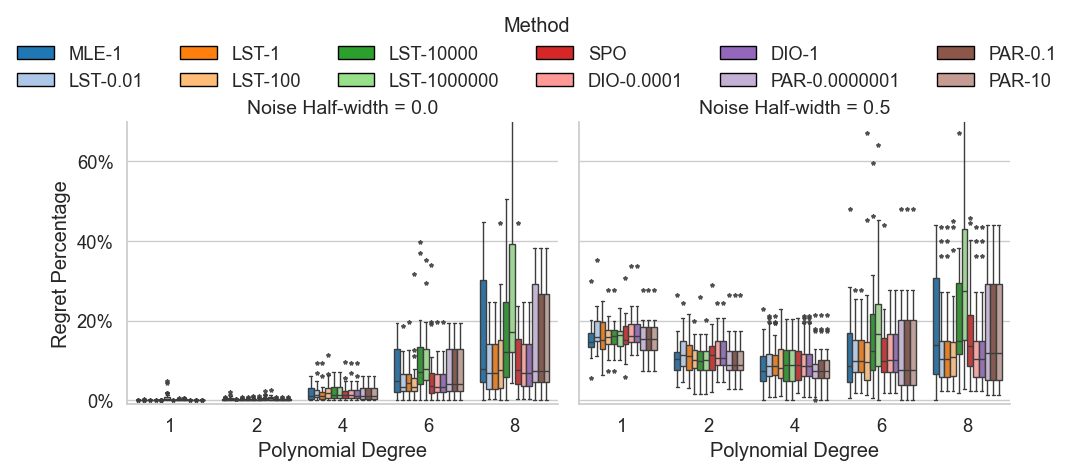

In [6]:
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)

file_path = os.path.join(save_path, f"Shortest_path_model_result_{grid_width}.pkl")
with open(file_path, "rb") as f:
    total_result = pickle.load(f)  # list of dicts: {"seed": s, "x": X_s, "y": Y_s}
df = pd.DataFrame(total_result)

df_long = (
    df
    .explode("regret")
    .rename(columns={"Deg": "Degree",
                     "Noise": "NoiseHalfWidth",
                     "Modeltype": "Method",
                     "regret": "Regret"})
)

df_long["Regret"] = df_long["Regret"].astype(float)

# ----------------------------------
# Seaborn setup
# ----------------------------------
sns.set(style="whitegrid", palette="tab20", font_scale=1.2)
palette = sns.color_palette("tab20")   # deep palette

methods = df_long["Method"].unique()
method_to_color = {m: palette[i % len(palette)] for i, m in enumerate(methods)}

# ----------------------------------
# Create the catplot
# ----------------------------------
g = sns.catplot(
    data=df_long,
    x="Degree",
    y="Regret",
    hue="Method",
    palette=method_to_color,
    col="NoiseHalfWidth",
    kind="box",
    height=4.5,
    aspect=1.1,
    sharey=True,
    legend=False,
    flierprops=dict(marker='*', markersize=3, linestyle='none', alpha=0.9)
)

# ----------------------------------
# Build LEGEND manually
# ----------------------------------
legend_handles = [
    Patch(facecolor=method_to_color[m], edgecolor='black', label=m)
    for m in methods
]

g.fig.legend(
    handles=legend_handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=6,
    frameon=False
)

# ----------------------------------
# Y-axis formatting + titles
# ----------------------------------
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.set_ylim(-0.01, 0.7)
    ax.set_ylabel("Regret Percentage")
    ax.set_xlabel("Polynomial Degree")

for ax, noise in zip(g.axes.flat, sorted(df_long["NoiseHalfWidth"].unique())):
    ax.set_title(f"Noise Half-width = {noise}", fontsize=14)

plt.subplots_adjust(top=0.80)


# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "model_sensitivity_analysis.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()


In [ ]:


# df_long columns:
#   NoiseHalfWidth, Degree, Method, Regret

def compute_stats(regrets):
    r = np.asarray(regrets, dtype=float)
    mean = r.mean()
    std  = r.std()
    var90 = np.percentile(r, 90)
    cvar90 = r[r >= var90].mean()
    return mean, std, var90, cvar90

rows = []

# Loop over ALL combinations
for noise in sorted(df_long["NoiseHalfWidth"].unique()):
    for deg in sorted(df_long["Degree"].unique()):
        for method in sorted(df_long["Method"].unique()):
            
            # Filter data for this (noise, deg, method)
            subset = df_long[
                (df_long["NoiseHalfWidth"] == noise) &
                (df_long["Degree"] == deg) &
                (df_long["Method"] == method)
            ]["Regret"].values
            
            # skip empty combinations
            if len(subset) == 0:
                continue
            
            mean, std, var90, cvar90 = compute_stats(subset)

            rows.append({
                "NoiseHalfWidth": noise,
                "Degree": deg,
                "Method": method,
                "Mean": mean,
                "Std": std,
                "VaR90": var90,
                "CVaR90": cvar90
            })

# Final DataFrame
df_stats = pd.DataFrame(rows)

def to_percent(x):
    return f"{x * 100:.3f}%"

df_stats_fmt = df_stats.copy()

for col in ["Mean", "Std", "VaR90", "CVaR90"]:
    df_stats_fmt[col] = df_stats_fmt[col].apply(to_percent)

df_stats_fmt

,NoiseHalfWidth,Degree,Method,Mean,Std,VaR90,CVaR90
0,0.0,1,DIO-0.0001,0.023%,0.044%,0.073%,0.126%
1,0.0,1,DIO-1,0.038%,0.087%,0.085%,0.245%
2,0.0,1,LST-0.01,0.003%,0.012%,0.001%,0.033%
3,0.0,1,LST-1,0.000%,0.000%,0.000%,0.000%
4,0.0,1,LST-100,0.000%,0.000%,0.000%,0.000%
...,...,...,...,...,...,...,...
115,0.5,8,MLE-1,14.283%,13.424%,30.375%,46.068%
116,0.5,8,PAR-0.0000001,13.655%,13.557%,30.375%,46.680%
117,0.5,8,PAR-0.1,13.655%,13.557%,30.375%,46.680%
118,0.5,8,PAR-10,13.655%,13.557%,30.375%,46.680%
